In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import sys
from pathlib import Path
from statsmodels.tsa.stattools import adfuller
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import lightgbm as lgb


PROJECT_ROOT = Path.cwd()
p = Path.cwd().resolve()
while p != p.parent and not (p / "extending_obs_space_analysis").exists():
    p = p.parent
PROJECT_ROOT = p

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Using project root:", PROJECT_ROOT)

from pathlib import Path
from extending_obs_space_analysis.prepare_data import PipelinePaths, build_training_dataframe

paths = PipelinePaths(
    drl_csv=Path("../data/data_2019-01-01_2025-09-30_hourly.csv"),

    ri_profit = Path("../output/single_market/profit.csv"),
    #ri_profit_2019_csv=Path("../output/single_market/rolling_intrinsic/ri_basic/qh/2019/bs15cr1rto0.86mc365mt10/profit.csv"),
    #ri_profit_2023_csv=Path("../output/single_market/rolling_intrinsic/ri_basic/qh/2023/bs15cr1rto0.86mc365mt10/profit.csv"),
    da_milp_exaa_csv=Path("../output/myopic_multi_market/day_ahead_milp/da_milp_results_exaa.csv"),
    da_milp_epex_csv=Path("../output/myopic_multi_market/day_ahead_milp/da_milp_results_epex.csv"),
)

df_daily = build_training_dataframe(paths, date_slice=("2019-01-01", "2025-09-30"))

Using project root: /Users/timflaschel/Documents/GitHub/BessBidder1


In [2]:
print(df_daily.columns.tolist())

['epex_price_mean', 'epex_price_std', 'epex_price_min', 'epex_price_max', 'exaa_price_mean', 'exaa_price_std', 'exaa_price_min', 'exaa_price_max', 'load_forecast_mean', 'load_forecast_std', 'load_forecast_min', 'load_forecast_max', 'pv_forecast_mean', 'pv_forecast_std', 'pv_forecast_min', 'pv_forecast_max', 'wind_offshore_forecast_mean', 'wind_offshore_forecast_std', 'wind_offshore_forecast_min', 'wind_offshore_forecast_max', 'wind_onshore_forecast_mean', 'wind_onshore_forecast_std', 'wind_onshore_forecast_min', 'wind_onshore_forecast_max', 'residual_load_forecast_mean', 'residual_load_forecast_std', 'residual_load_forecast_min', 'residual_load_forecast_max', 'id_full_h_mean', 'id_full_h_std', 'id_full_h_min', 'id_full_h_max', 'epex_price_spread', 'id_full_h_spread', 'exaa_price_spread', 'residual_load_forecast_spread', 'spread_id_full_da_h_mean_lag1', 'spread_id_full_da_h_std_lag1', 'spread_id_full_da_h_min_lag1', 'spread_id_full_da_h_max_lag1', 'day_of_week', 'month', 'year', 'epex_p

In [3]:
drop_columns = [

'epex_price_mean', 'epex_price_std', 'epex_price_min', 'epex_price_max',

'load_forecast_mean', 'load_forecast_std', 'load_forecast_min', 'load_forecast_max',
'pv_forecast_mean', 'pv_forecast_std', 'pv_forecast_min', 'pv_forecast_max',
 'wind_offshore_forecast_min', 'wind_offshore_forecast_max',
 'wind_onshore_forecast_min', 'wind_onshore_forecast_max',
'residual_load_forecast_mean', 'residual_load_forecast_std', 'residual_load_forecast_min', 'residual_load_forecast_max',
'id_full_h_mean', 'id_full_h_std', 'id_full_h_min', 'id_full_h_max', 
'epex_price_spread', 'id_full_h_spread', 
'residual_load_forecast_spread',  'epex_price_delta_sum', 'epex_price_delta_max',
'epex_price_delta_min', 
'pv_delta_sum', 'pv_delta_max', 'pv_delta_min',
'wind_onshore_delta_sum', 'wind_onshore_delta_max', 'wind_onshore_delta_min',
'wind_offshore_delta_sum', 'wind_offshore_delta_max', 'wind_offshore_delta_min',
'residual_load_delta_sum', 'residual_load_delta_max', 'residual_load_delta_min',
'exaa_std_roll1d_mean_lag0', 'exaa_std_roll3d_mean_lag0', 'exaa_std_roll7d_mean_lag0',
'exaa_std_roll14d_mean_lag0', 'exaa_std_roll30d_mean_lag0', 'exaa_std_roll90d_mean_lag0',
'exaa_spread_roll3d_mean_lag0', 'exaa_spread_roll7d_mean_lag0', 'exaa_spread_roll14d_mean_lag0',
'exaa_spread_roll30d_mean_lag0', 'exaa_spread_roll90d_mean_lag0', 'epex_spread_roll3d_mean_lag1',
'epex_spread_roll7d_mean_lag1', 'epex_spread_roll14d_mean_lag1', 'epex_spread_roll30d_mean_lag1',
'epex_spread_roll90d_mean_lag1', 'id_full_h_std_roll3d_mean_lag1', 'id_full_h_std_roll7d_mean_lag1',
'id_full_h_spread_roll3d_mean_lag1', 'id_full_h_spread_roll7d_mean_lag1', 'id_full_h_spread_roll14d_mean_lag1',
'id_full_h_spread_roll30d_mean_lag1', 'id_full_h_spread_roll90d_mean_lag1', 'wind_onshore_std_roll3d_mean_lag0',
'wind_onshore_std_roll7d_mean_lag0', 'wind_offshore_std_roll3d_mean_lag0', 'wind_offshore_std_roll7d_mean_lag0',
'residual_load_std_roll3d_mean_lag0', 'residual_load_std_roll7d_mean_lag0', 'residual_load_std_roll14d_mean_lag0',
'residual_load_std_roll30d_mean_lag0', 'pv_std_roll3d_mean_lag0', 'pv_std_roll7d_mean_lag0', 
'combo_id', 'kind', 'buy_hour', 'sell_hour',  'da_profit_exaa', 'da_profit_epex', 'da_idc_profit_diff','exaa_price_delta_min',


'exaa_price_mean',
 'exaa_price_std',
   'exaa_price_min',
     'exaa_price_max', 
     'exaa_price_spread',
     'exaa_price_delta_sum',
       'exaa_price_delta_max', 



]

df_daily = df_daily.drop(columns=drop_columns)

In [4]:
df_daily.columns

Index(['wind_offshore_forecast_mean', 'wind_offshore_forecast_std',
       'wind_onshore_forecast_mean', 'wind_onshore_forecast_std',
       'spread_id_full_da_h_mean_lag1', 'spread_id_full_da_h_std_lag1',
       'spread_id_full_da_h_min_lag1', 'spread_id_full_da_h_max_lag1',
       'day_of_week', 'month', 'year', 'ri_profit'],
      dtype='object')

In [5]:
""""

'ri_profit',
'wind_offshore_forecast_mean', 
'wind_offshore_forecast_std',
'wind_onshore_forecast_mean', 
'wind_onshore_forecast_std',
'day_of_week',
'month',
'year',
"spread_id_full_da_h_mean_lag1",
"spread_id_full_da_h_std_lag1",
"spread_id_full_da_h_min_lag1",
"spread_id_full_da_h_max_lag1",


'exaa_price_mean',
 'exaa_price_std',
   'exaa_price_min',
     'exaa_price_max', 
     'exaa_price_spread',
     'exaa_price_delta_sum',
       'exaa_price_delta_max', 
       

"""

'"\n\n\'ri_profit\',\n\'wind_offshore_forecast_mean\', \n\'wind_offshore_forecast_std\',\n\'wind_onshore_forecast_mean\', \n\'wind_onshore_forecast_std\',\n\'day_of_week\',\n\'month\',\n\'year\',\n"spread_id_full_da_h_mean_lag1",\n"spread_id_full_da_h_std_lag1",\n"spread_id_full_da_h_min_lag1",\n"spread_id_full_da_h_max_lag1",\n\n\n\'exaa_price_mean\',\n \'exaa_price_std\',\n   \'exaa_price_min\',\n     \'exaa_price_max\', \n     \'exaa_price_spread\',\n     \'exaa_price_delta_sum\',\n       \'exaa_price_delta_max\', \n       \n\n'

In [6]:
for col in df_daily.columns:
    print(col)

df_dail = df_daily


wind_offshore_forecast_mean
wind_offshore_forecast_std
wind_onshore_forecast_mean
wind_onshore_forecast_std
spread_id_full_da_h_mean_lag1
spread_id_full_da_h_std_lag1
spread_id_full_da_h_min_lag1
spread_id_full_da_h_max_lag1
day_of_week
month
year
ri_profit


In [7]:
df_daily.tail()

,wind_offshore_forecast_mean,wind_offshore_forecast_std,wind_onshore_forecast_mean,wind_onshore_forecast_std,spread_id_full_da_h_mean_lag1,spread_id_full_da_h_std_lag1,spread_id_full_da_h_min_lag1,spread_id_full_da_h_max_lag1,day_of_week,month,year,ri_profit
date,,,,,,,,,,,,
2025-09-26 00:00:00+00:00,4998.050208,398.244890,15130.320625,1074.953659,13.199812,22.158250,-16.057984,58.377098,4,9,2025,89.488307
2025-09-27 00:00:00+00:00,2717.512500,651.882783,7523.266667,2479.177245,8.383876,11.886945,-12.424988,38.578672,5,9,2025,119.997681
2025-09-28 00:00:00+00:00,756.943542,217.328558,3603.847500,2415.421700,8.243826,13.695855,-17.679830,48.367130,6,9,2025,161.623996
2025-09-29 00:00:00+00:00,643.101979,237.094721,3962.615833,1860.304438,0.405243,6.849920,-15.033944,15.587949,0,9,2025,322.956761
2025-09-30 00:00:00+00:00,923.909318,356.743953,5140.619659,2077.534195,-12.167825,35.083413,-146.625553,19.673839,1,9,2025,279.067717


### LGB Regressor 

In [8]:
# Data prep
# ------------------------------------------------------------------

df = df_daily.copy().reset_index(drop=True)
target = "ri_profit"

# nur numerische ex-ante Features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = {target, "cycles"}
feature_cols = [c for c in numeric_cols if c not in exclude]

df = df.dropna(subset=[target]).reset_index(drop=True)

X = df[feature_cols]
y = df[target].values

# Columns that are entirely NaN cannot be median-imputed; sklearn may drop them
# and the output shape would no longer match feature_cols.
usable = [c for c in feature_cols if X[c].notna().any()]
dropped = sorted(set(feature_cols) - set(usable))
if dropped:
    print("Dropping all-NaN feature columns:", dropped)
feature_cols = usable
X = df[feature_cols]

# Imputation
imputer = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)

n = len(df)
print("Total observations:", n)


# Rolling window setup
# ------------------------------------------------------------------

train_size = 730
test_size  = 180
step_size  = 180


# LightGBM Regressor
# ------------------------------------------------------------------

params = dict(
    objective="regression",
    metric="rmse",
    learning_rate=0.05,
    n_estimators=2000,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.5,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)


# Rolling CV
# ------------------------------------------------------------------

rows = []
models = []

fold = 0
start = 0

while start + train_size + test_size <= n:
    fold += 1

    train_idx = slice(start, start + train_size)
    test_idx  = slice(start + train_size, start + train_size + test_size)

    X_train = X_imp.iloc[train_idx]
    X_test  = X_imp.iloc[test_idx]
    y_train = y[train_idx]
    y_test  = y[test_idx]

    reg = lgb.LGBMRegressor(**params)
    reg.fit(
        X_train,
        y_train,
        eval_set=[(X_test, y_test)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )

    y_pred = reg.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    rows.append({
        "fold": fold,
        "train_start": start,
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2),
        "best_iter": int(getattr(reg, "best_iteration_", None) or params["n_estimators"])
    })

    models.append(reg)
    start += step_size


# Results
# ------------------------------------------------------------------

rw_df = pd.DataFrame(rows)

print("\nRolling Window CV Results (Point Forecast)")
print(rw_df)

print("\nRolling Window CV Means")
print(rw_df.drop(columns=["fold", "train_start"]).mean(numeric_only=True))



Total observations: 2464

Rolling Window CV Results (Point Forecast)
   fold  train_start         MAE        RMSE        R2  best_iter
0     1            0   34.684211   49.140705  0.189249        164
1     2          180   88.886536  124.018459 -0.290072        238
2     3          360  130.693303  173.224006 -1.102477        146
3     4          540  136.203367  194.763289 -0.004488        340
4     5          720   99.386483  116.815446 -0.651647          1
5     6          900   86.301937  196.021923  0.080864         85
6     7         1080   81.138606  147.558981  0.175455        124
7     8         1260   74.115356  106.396421  0.134109         95
8     9         1440   88.003258  174.525180  0.213682       1046

Rolling Window CV Means
MAE           91.045895
RMSE         142.496045
R2            -0.139481
best_iter    248.777778
dtype: float64


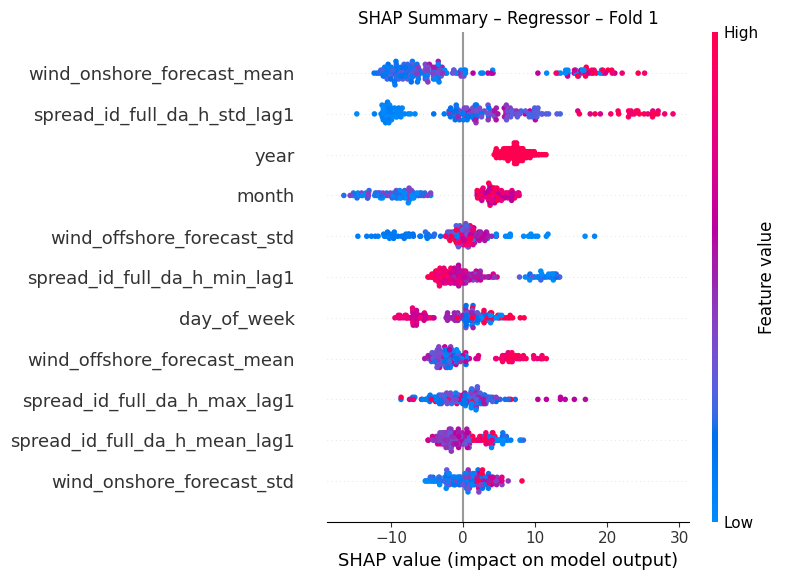

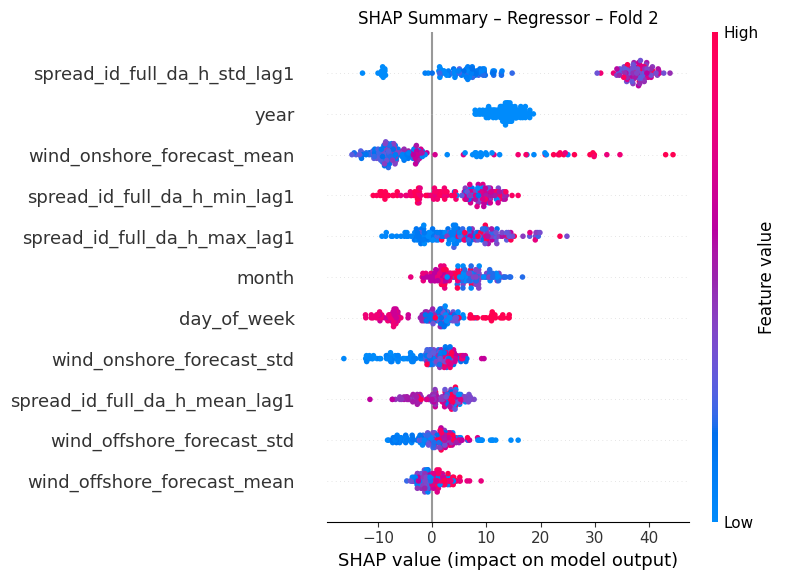

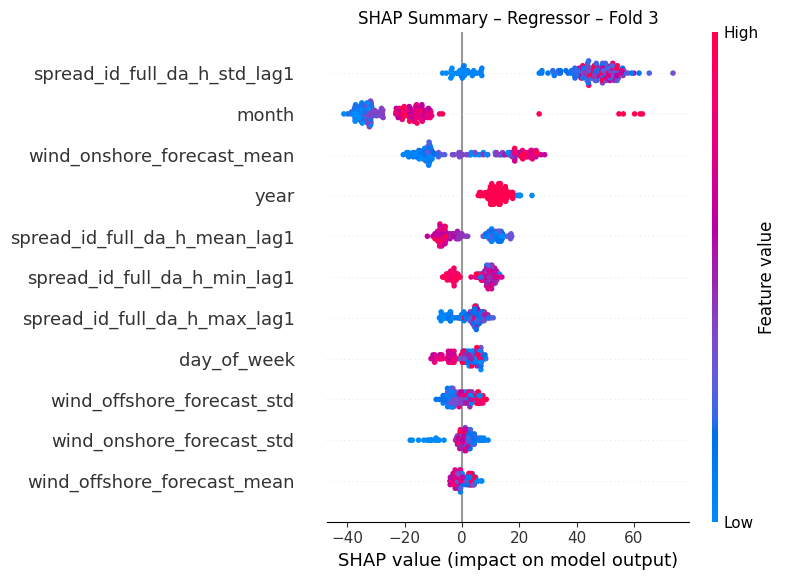

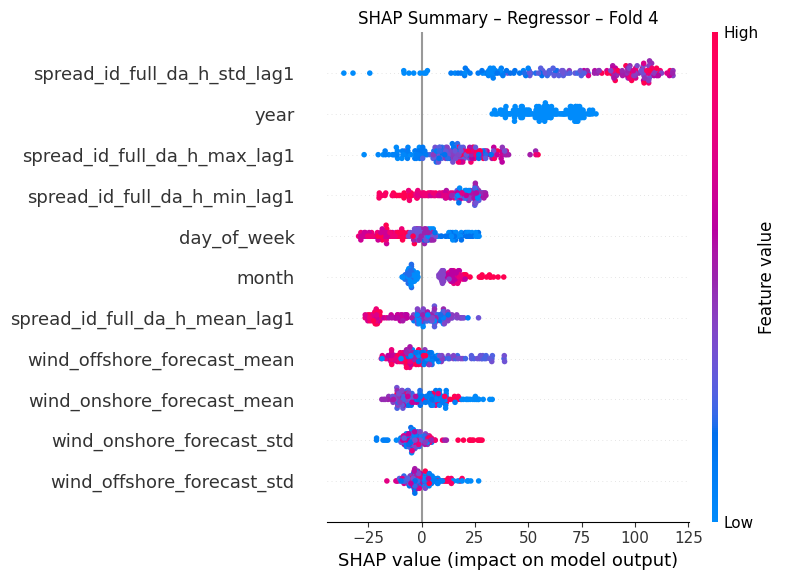

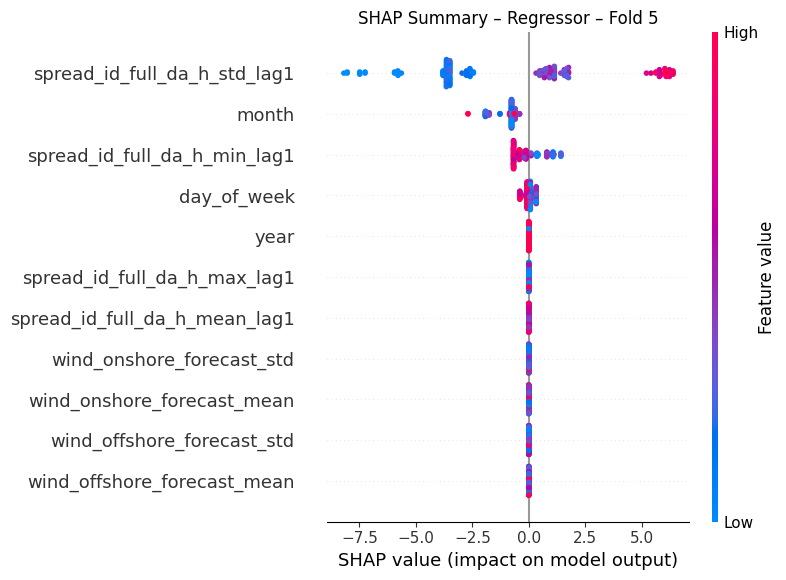

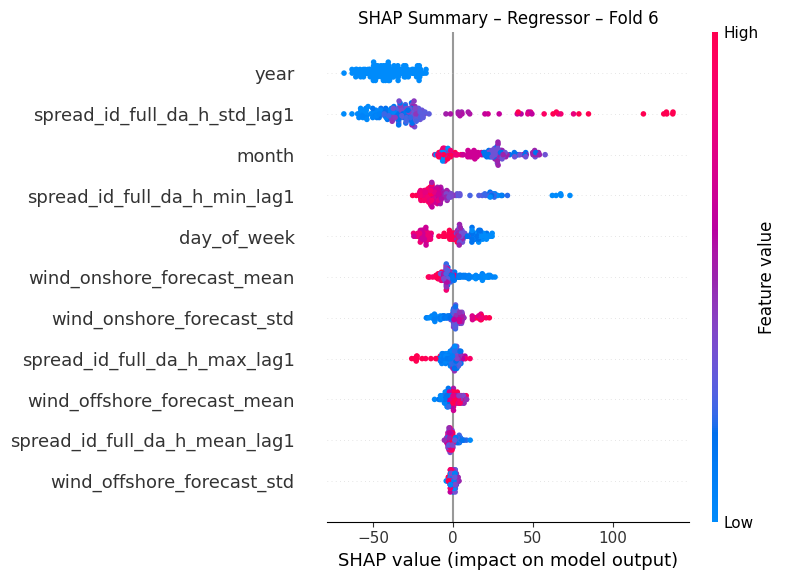

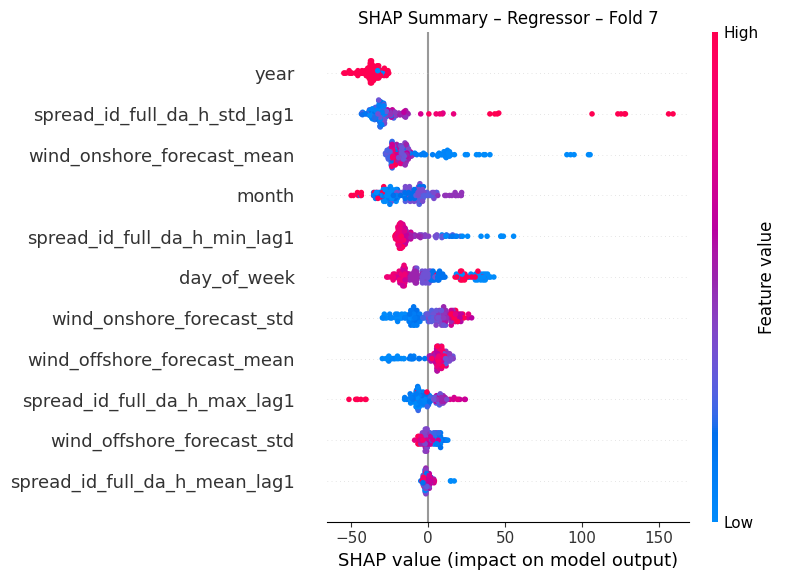

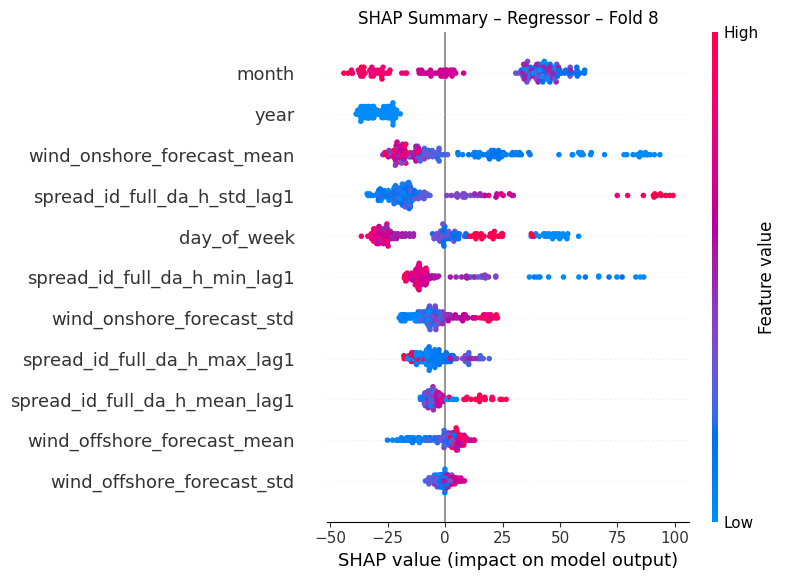

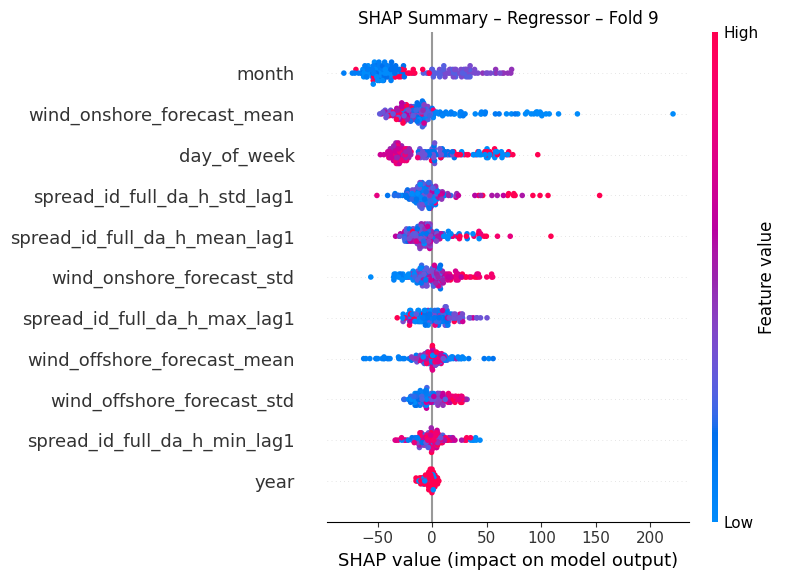

                                    mean        std
feature                                            
spread_id_full_da_h_std_lag1   28.596961  20.484935
year                           22.417982  19.762112
month                          17.948073  12.839324
wind_onshore_forecast_mean     13.735719   9.312269
day_of_week                    11.297606   9.294133
spread_id_full_da_h_min_lag1   10.202404   5.928067
spread_id_full_da_h_max_lag1    7.350704   5.472607
wind_onshore_forecast_std       6.219456   4.735399
spread_id_full_da_h_mean_lag1   5.675846   5.040282
wind_offshore_forecast_mean     5.365693   4.160810
wind_offshore_forecast_std      3.967009   3.327871


In [9]:
import shap
import lightgbm as lgb
import matplotlib.pyplot as plt


from sklearn.impute import SimpleImputer

df = df_daily.copy().reset_index(drop=True)
target = "ri_profit"

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = {target, "cycles"}
feature_cols = [c for c in numeric_cols if c not in exclude]

df = df.dropna(subset=[target]).reset_index(drop=True)

X = df[feature_cols]
y = df[target].values

usable = [c for c in feature_cols if X[c].notna().any()]
dropped = sorted(set(feature_cols) - set(usable))
if dropped:
    print("Dropping all-NaN feature columns:", dropped)
feature_cols = usable
X = df[feature_cols]

train_size = 730
test_size  = 180
step_size  = 180

params = dict(
    objective="regression",
    learning_rate=0.05,
    n_estimators=1000,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

shap_results = []

fold = 0
start = 0

while start + train_size + test_size <= len(df):
    fold += 1

    train_idx = slice(start, start + train_size)
    test_idx  = slice(start + train_size, start + train_size + test_size)

    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y[train_idx]
    y_test  = y[test_idx]

    # leakage-freie Imputation
    imputer = SimpleImputer(strategy="median")
    X_train_imp = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=feature_cols,
        index=X_train.index
    )
    X_test_imp = pd.DataFrame(
        imputer.transform(X_test),
        columns=feature_cols,
        index=X_test.index
    )

    reg = lgb.LGBMRegressor(**params)
    reg.fit(
        X_train_imp, y_train,
        eval_set=[(X_test_imp, y_test)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )

    # --- SHAP: robust (kein Additivity-Error) ---
    explainer = shap.TreeExplainer(reg, data=X_train_imp)

    tree_limit = getattr(reg, "best_iteration_", None)
    shap_vals = explainer.shap_values(
        X_test_imp,
        check_additivity=False,
        tree_limit=tree_limit
    )

    # shap_vals: (n_samples, n_features)
    shap_vals = np.asarray(shap_vals)
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)

    shap_results.append(pd.DataFrame({
        "feature": feature_cols,
        "mean_abs_shap": mean_abs_shap,
        "fold": fold
    }))

    # Summary plot
    plt.figure()
    shap.summary_plot(
        shap_vals,
        X_test_imp,
        feature_names=feature_cols,
        show=False,
        max_display=15
    )
    plt.title(f"SHAP Summary – Regressor – Fold {fold}")
    plt.tight_layout()
    plt.show()

    start += step_size

shap_df = pd.concat(shap_results, ignore_index=True)

# Optional: Aggregation über Folds
shap_summary = (
    shap_df.groupby("feature")["mean_abs_shap"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
)

print(shap_summary.head(20))

#### LGB Classifier

In [10]:
import numpy as np
import pandas as pd
import lightgbm as lgb

from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score

# Helper metrics
# ------------------------------------------------------------------

def precision_at_k(y_true, y_score, k_frac=0.2):
    n = len(y_true)
    k = max(1, int(np.ceil(n * k_frac)))
    idx = np.argsort(y_score)[::-1][:k]
    return float(np.mean(y_true[idx]))

def recall_at_k(y_true, y_score, k_frac=0.2):
    n = len(y_true)
    k = max(1, int(np.ceil(n * k_frac)))
    idx = np.argsort(y_score)[::-1][:k]
    denom = np.sum(y_true)
    return float(np.sum(y_true[idx]) / denom) if denom > 0 else np.nan

# Data prep
# ------------------------------------------------------------------

df = df_daily.copy().reset_index(drop=True)
target = "ri_profit"

# nur numerische ex-ante Features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = {target, "cycles"}
feature_cols = [c for c in numeric_cols if c not in exclude]

df = df.dropna(subset=[target]).reset_index(drop=True)

X = df[feature_cols]
y = df[target].values

usable = [c for c in feature_cols if X[c].notna().any()]
dropped = sorted(set(feature_cols) - set(usable))
if dropped:
    print("Dropping all-NaN feature columns:", dropped)
feature_cols = usable
X = df[feature_cols]

# Imputation
imputer = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)

n = len(df)
print("Total observations:", n)

# Rolling window setup
# ------------------------------------------------------------------

train_size = 730
test_size  = 180
step_size  = 180

q_high = 0.8
k_frac = 0.20

# LightGBM parameters
# ------------------------------------------------------------------

params = dict(
    objective="binary",
    metric="auc",
    learning_rate=0.05,
    n_estimators=2000,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.5,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Rolling CV
# ------------------------------------------------------------------

rows = []
models = []

fold = 0
start = 0

while start + train_size + test_size <= n:
    fold += 1

    train_idx = slice(start, start + train_size)
    test_idx  = slice(start + train_size, start + train_size + test_size)

    X_train = X_imp.iloc[train_idx]
    X_test  = X_imp.iloc[test_idx]

    y_train_cont = y[train_idx]
    y_test_cont  = y[test_idx]

    # Threshold nur aus Train
    thr = np.quantile(y_train_cont, q_high)
    y_train = (y_train_cont > thr).astype(int)
    y_test  = (y_test_cont  > thr).astype(int)

    # skip folds ohne beide Klassen
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        start += step_size
        continue

    clf = lgb.LGBMClassifier(**params)
    clf.fit(
        X_train,
        y_train,
        eval_set=[(X_test, y_test)],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )

    p_test = clf.predict_proba(X_test)[:, 1]

    rows.append({
        "fold": fold,
        "train_start": start,
        "thr_profit": float(thr),
        "test_pos_rate": float(y_test.mean()),
        "AUC": roc_auc_score(y_test, p_test),
        f"Precision@{int(k_frac*100)}%": precision_at_k(y_test, p_test, k_frac),
        f"Recall@{int(k_frac*100)}%": recall_at_k(y_test, p_test, k_frac),
        "best_iter": int(clf.best_iteration_ or params["n_estimators"])
    })

    models.append(clf)
    start += step_size

# Results
# ------------------------------------------------------------------

rw_df = pd.DataFrame(rows)

print("\nRolling Window CV Results")
print(rw_df)

print("\nRolling Window CV Means")
print(rw_df.drop(columns=["fold", "train_start"]).mean(numeric_only=True))



Total observations: 2464

Rolling Window CV Results
   fold  train_start  thr_profit  test_pos_rate       AUC  Precision@20%  \
0     1            0  105.478246       0.416667  0.738921       0.750000   
1     2          180  120.544750       0.783333  0.876250       1.000000   
2     3          360  182.261513       0.911111  0.848704       1.000000   
3     4          540  275.657235       0.800000  0.817323       0.944444   
4     5          720  383.728208       0.033333  0.750000       0.111111   
5     6          900  392.836574       0.066667  0.836806       0.222222   
6     7         1080  398.950172       0.044444  0.859012       0.194444   
7     8         1260  365.420564       0.072222  0.802395       0.194444   
8     9         1440  258.663388       0.122222  0.731876       0.305556   

   Recall@20%  best_iter  
0    0.360000        614  
1    0.255319         39  
2    0.219512         63  
3    0.236111         39  
4    0.666667       1057  
5    0.666667         70 

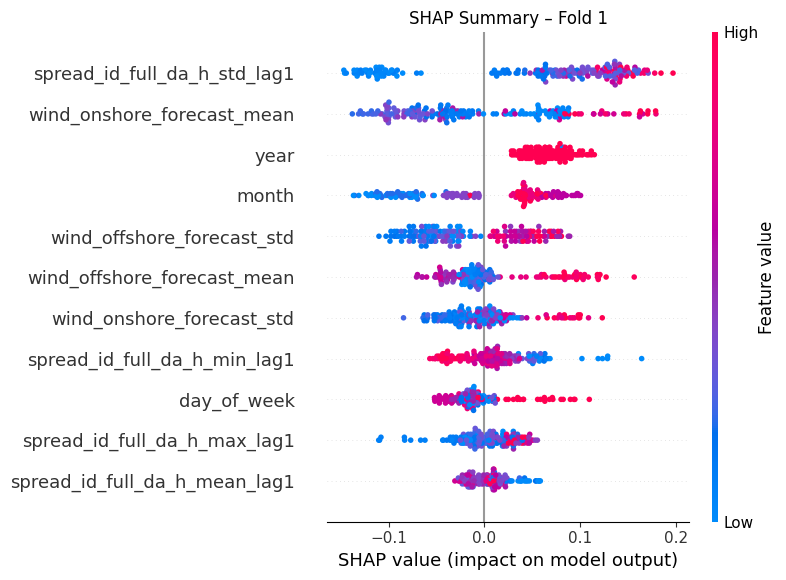

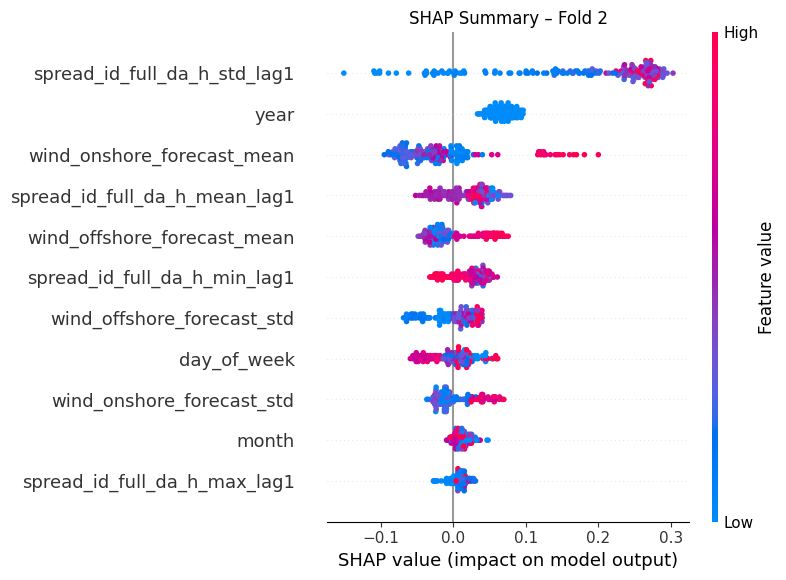

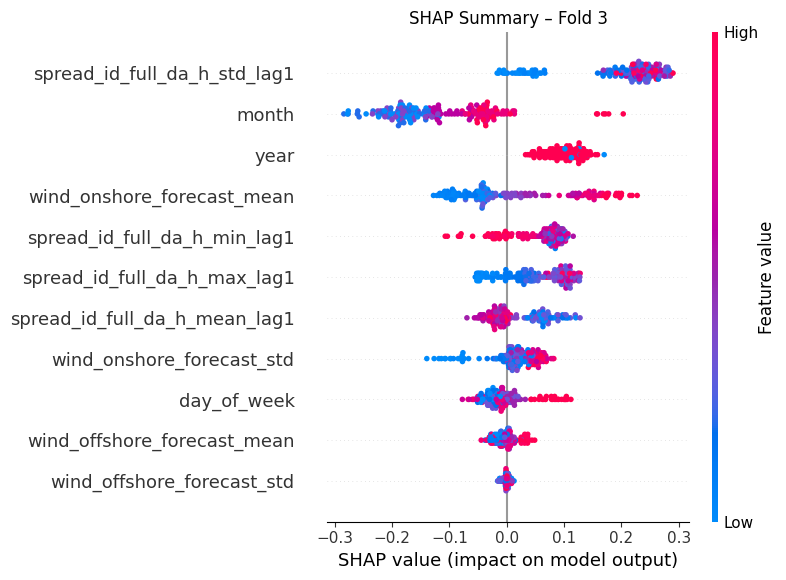

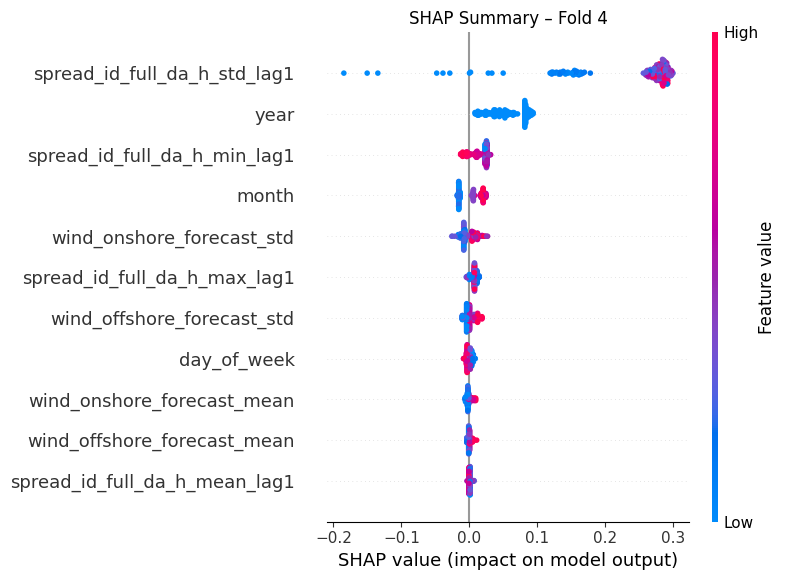

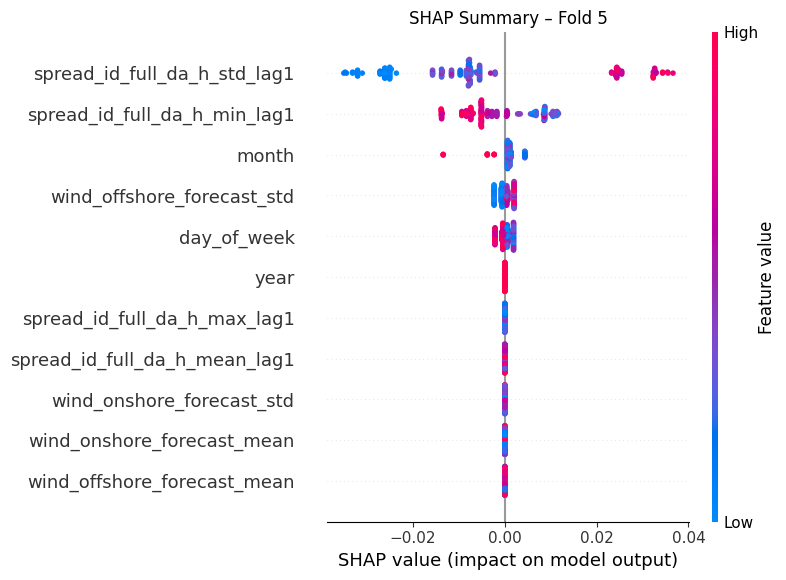

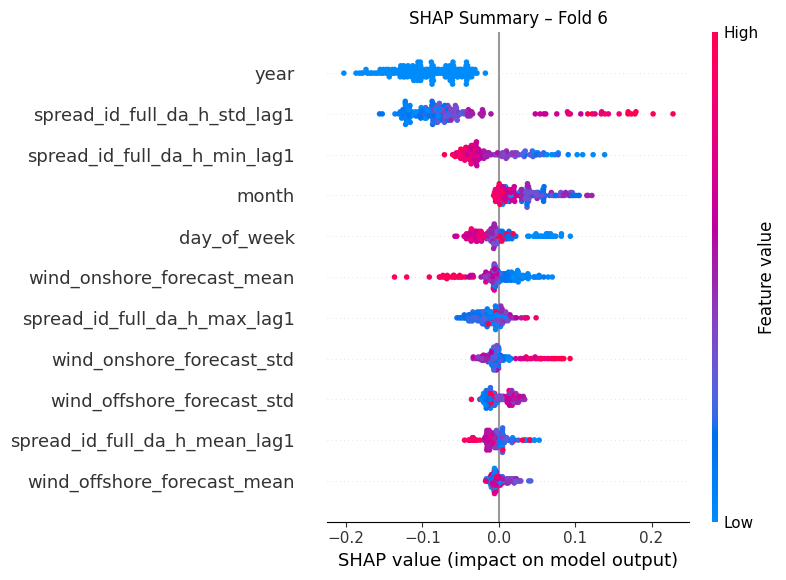

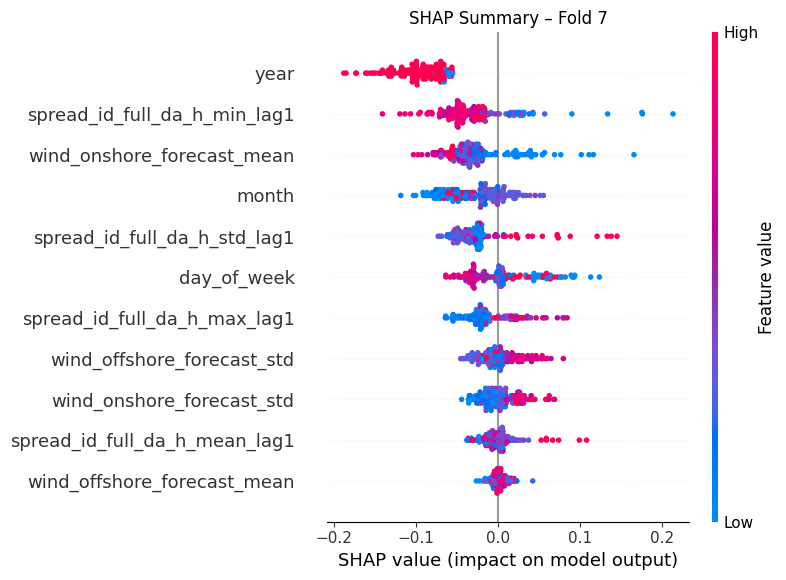

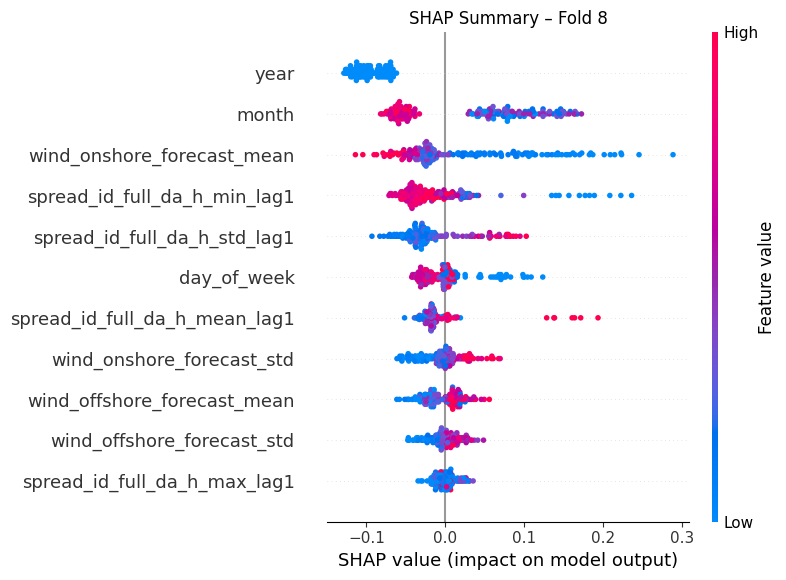

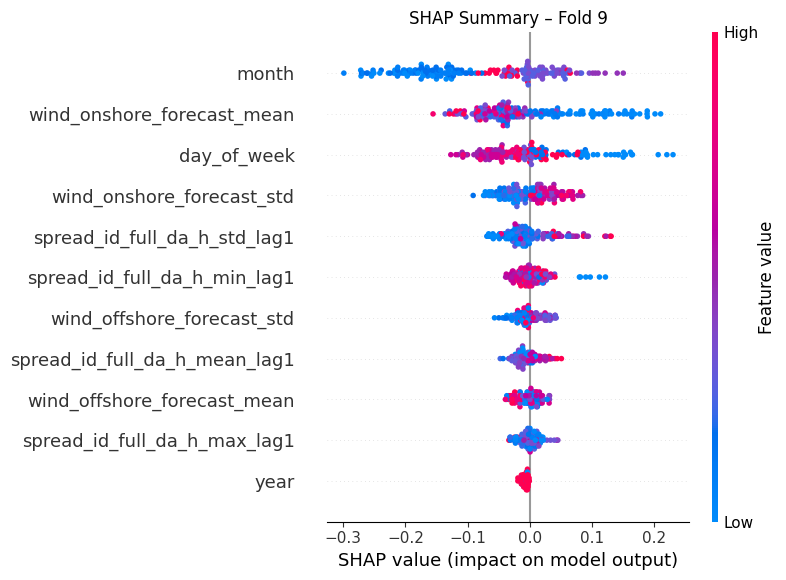

In [11]:
import shap
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score

df = df_daily.copy().reset_index(drop=True)
target = "ri_profit"

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = {target, "cycles"}
feature_cols = [c for c in numeric_cols if c not in exclude]

df = df.dropna(subset=[target]).reset_index(drop=True)

X = df[feature_cols]
y = df[target].values

usable = [c for c in feature_cols if X[c].notna().any()]
dropped = sorted(set(feature_cols) - set(usable))
if dropped:
    print("Dropping all-NaN feature columns:", dropped)
feature_cols = usable
X = df[feature_cols]

imputer = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)

# Rolling Window Parameter
train_size = 730
test_size  = 180
step_size  = 180
q_high     = 0.7

params = dict(
    objective="binary",
    learning_rate=0.05,
    n_estimators=1000,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

shap_results = []

fold = 0
start = 0

while start + train_size + test_size <= len(df):
    fold += 1

    train_idx = slice(start, start + train_size)
    test_idx  = slice(start + train_size, start + train_size + test_size)

    X_train = X_imp.iloc[train_idx]
    X_test  = X_imp.iloc[test_idx]
    y_train_cont = y[train_idx]
    y_test_cont  = y[test_idx]

    thr = np.quantile(y_train_cont, q_high)
    y_train = (y_train_cont > thr).astype(int)
    y_test  = (y_test_cont  > thr).astype(int)

    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        start += step_size
        continue

    clf = lgb.LGBMClassifier(**params)
    clf.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )
    explainer = shap.Explainer(
        clf,
        X_train,
        model_output="probability"
    )

    shap_exp = explainer(X_test)

    # Matrix: (n_samples, n_features)
    shap_vals = shap_exp.values

    assert shap_vals.ndim == 2
    assert shap_vals.shape[1] == X_test.shape[1]

    mean_abs_shap = np.abs(shap_vals).mean(axis=0)

    shap_results.append(
        pd.DataFrame({
            "feature": feature_cols,
            "mean_abs_shap": mean_abs_shap,
            "fold": fold
        })
    )



    
    # Shap sumamry plot
    plt.figure()
    shap.summary_plot(
        shap_vals, X_test,
        feature_names=feature_cols,
        show=False,
        max_display=15
    )
    
    plt.title(f"SHAP Summary – Fold {fold}")
    plt.tight_layout()
    plt.show()
    
    start += step_size

shap_df = pd.concat(shap_results, ignore_index=True)


In [12]:
# aggregate SHAP values over all folds
shap_agg = (
    shap_df
    .groupby("feature")["mean_abs_shap"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
)

print(shap_agg.head(50))


                                   mean       std
feature                                          
spread_id_full_da_h_std_lag1   0.104965  0.084106
year                           0.064576  0.037852
month                          0.052274  0.043426
wind_onshore_forecast_mean     0.044516  0.030028
spread_id_full_da_h_min_lag1   0.031735  0.018047
day_of_week                    0.023405  0.015472
wind_onshore_forecast_std      0.019795  0.011117
spread_id_full_da_h_max_lag1   0.018389  0.018002
spread_id_full_da_h_mean_lag1  0.016560  0.012914
wind_offshore_forecast_std     0.016237  0.014775
wind_offshore_forecast_mean    0.014006  0.011925
